# Hands-On 9: Learning across datasets

Worked responses accompany the same experiments.

In [1]:
from pathlib import Path
import os
import sys
try:
    import mlcourse.setup
except ModuleNotFoundError:
    bases = [Path(os.environ.get("MLCOURSE_ROOT", Path.cwd())), Path.cwd(), Path("/content/pp-machine-learning")]
    for base in bases:
        for candidate in (base.resolve(), *base.resolve().parents):
            if (candidate / "src/mlcourse/setup.py").is_file():
                sys.path.insert(0, str(candidate / "src"))
                break
        else:
            continue
        break
    else:
        raise RuntimeError("Course files not found. Open the extracted course repository or set MLCOURSE_ROOT to its location.") from None

In [2]:
from mlcourse.setup import setup_notebook
REPO_ROOT = setup_notebook()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.tree import DecisionTreeRegressor, plot_tree
from mlcourse.labs import load_meta_dataset
from mlcourse.widgets import interactive_meta_performance

## 1. Inspect a different kind of observation

Load the meta-learning dataframe.

**Prediction:** What does one row represent here?

One row represents an entire learning task or dataset, rather than one observation inside a dataset.

In [3]:
meta_data = load_meta_dataset()
display(meta_data.head())
print(f'Datasets: {len(meta_data)}')

,dataset,n_instances,n_features,n_classes,class_imbalance,...,tree_accuracy,stump_accuracy,majority_accuracy,accuracy_gap,tree_wins
0,kr-vs-kp,2237,36,2,1.093,...,0.992,0.678,0.522,0.314,1
1,balance-scale,437,4,3,5.941,...,0.745,0.585,0.457,0.160,1
2,breast-w,489,9,2,1.893,...,0.948,0.914,0.657,0.033,1
3,credit-g,700,20,2,2.333,...,0.647,0.700,0.700,-0.053,0
4,diabetes,537,8,2,1.872,...,0.762,0.693,0.649,0.069,1


Datasets: 12


**Observation:** Identify the dataset-level descriptors and algorithm-performance columns.

The table contains descriptors such as training-set size, number of features, number of classes, class imbalance and class entropy. It also contains measured accuracies for the full tree, stump and majority-class strategy.

**Explanation:** How does this differ from predicting the class of an individual observation?

The learning problem has moved up one level. The objects being described are datasets, and the targets describe how learning strategies behave on those datasets.

## 2. Compare model capacity across datasets

Compute full-tree accuracy minus stump accuracy and inspect the ordering.

**Prediction:** Can a simpler stump outperform the full tree on some datasets? Why?

Yes. The full tree has greater capacity, but that does not guarantee better generalisation. A stump can sometimes benefit from lower variance or from a task whose dominant structure is simple.

,dataset,tree_accuracy,stump_accuracy,accuracy_gap
11,blood-transfusion-service-center,0.693,0.760,-0.067
5,sonar,0.619,0.683,-0.063
3,credit-g,0.647,0.700,-0.053
2,breast-w,0.948,0.914,0.033
4,diabetes,0.762,0.693,0.069
1,balance-scale,0.745,0.585,0.160
10,banknote-authentication,0.988,0.825,0.163
6,tic-tac-toe,0.913,0.688,0.226
8,iris,0.933,0.667,0.267
7,vehicle,0.693,0.406,0.287


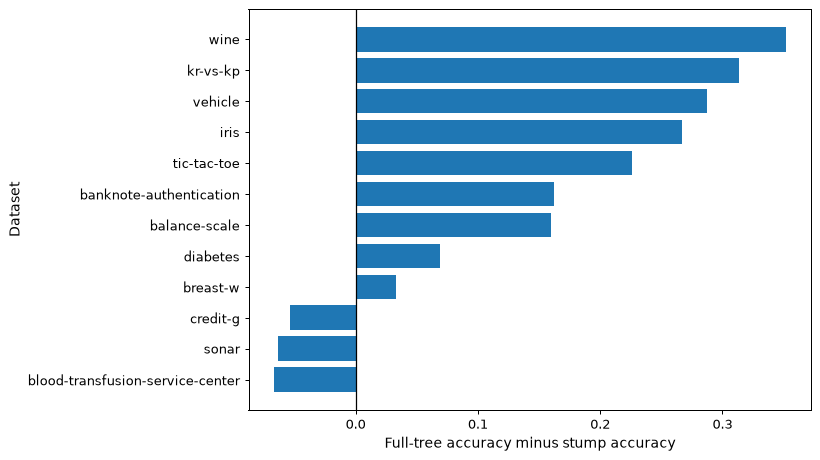

In [4]:
ordered = meta_data.sort_values('accuracy_gap')
display(ordered[['dataset', 'tree_accuracy', 'stump_accuracy', 'accuracy_gap']])
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
ax.barh(ordered.dataset, ordered.accuracy_gap)
ax.axvline(0, color='black', linewidth=1)
ax.set(xlabel='Full-tree accuracy minus stump accuracy', ylabel='Dataset')
plt.show()

**Observation:** Which datasets favour each tree model?

Most tasks favour the full tree, while credit-g, sonar and blood-transfusion-service-center favour the stump in the retained results.

**Explanation:** Explain how model capacity can contribute to this variation.

A full tree can represent more detailed partitions of the feature space. That flexibility can help when the task contains complex structure, but it can also make the fitted model more sensitive to limited or noisy training data.

## 3. Relate task descriptors to the performance gap

Plot class imbalance and feature count against the full-tree minus stump accuracy gap.

**Prediction:** Should either descriptor determine the winner perfectly?

No. These are coarse summaries of a dataset and cannot capture all of its geometry, noise, interactions or sampling effects.

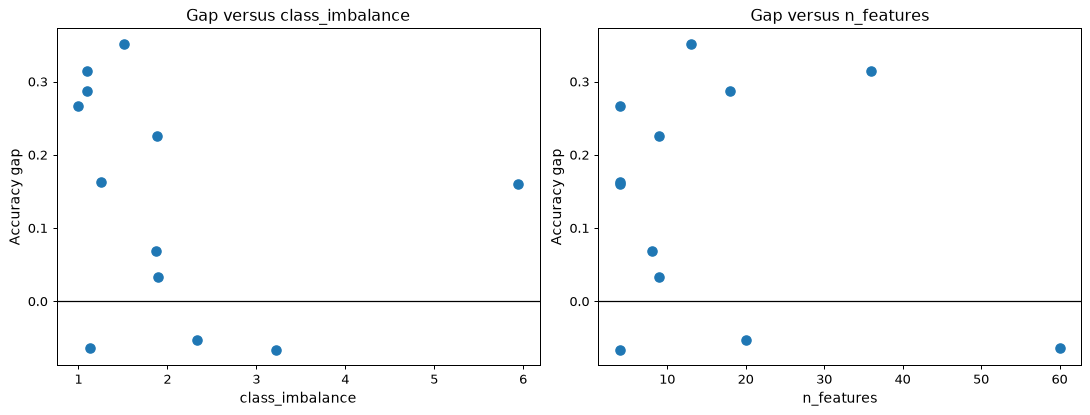

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout='constrained')
for ax, feature in zip(axes, ['class_imbalance', 'n_features']):
    ax.scatter(meta_data[feature], meta_data.accuracy_gap, s=55)
    ax.axhline(0, color='black', linewidth=1)
    ax.set(xlabel=feature, ylabel='Accuracy gap', title=f'Gap versus {feature}')
plt.show()

**Observation:** Look for different outcomes at similar descriptor values.

Tasks with comparable imbalance or feature counts can still have performance gaps with different signs and magnitudes.

**Explanation:** Why can one dataset summary conceal important structure in the underlying feature space?

Two datasets can share the same number of features or similar class proportions while differing substantially in overlap, nonlinear structure, interactions and noise. A single meta-feature therefore compresses away information that can matter to the learner.

## 4. Predict algorithm performance

A binary winner discards information. Instead, predict the measured accuracy of three candidate strategies for an unseen dataset: a full decision tree, a decision stump, and a majority-class baseline. Each leave-one-dataset-out prediction is made without using the held-out dataset's measured accuracies.

**Prediction:** What advantage is gained by predicting performance values instead of only predicting which model wins?

Performance prediction retains magnitude. It can distinguish a near tie from a large advantage and allows several candidate strategies to be ranked from the same predicted scores.

In [6]:
meta_features = ['n_instances', 'n_features', 'n_classes', 'class_imbalance', 'numeric_ratio', 'class_entropy']
performance_columns = ['tree_accuracy', 'stump_accuracy', 'majority_accuracy']
strategy_names = {
    'tree_accuracy': 'Full tree',
    'stump_accuracy': 'Decision stump',
    'majority_accuracy': 'Majority baseline',
}

X_meta = meta_data[meta_features]
y_performance = meta_data[performance_columns]
loo = LeaveOneOut()
meta_regressor = RandomForestRegressor(
    n_estimators=300,
    max_depth=3,
    min_samples_leaf=2,
    random_state=42,
)
predicted_performance = cross_val_predict(meta_regressor, X_meta, y_performance, cv=loo)

observed = y_performance.to_numpy()
mean_baseline = np.empty_like(observed)
for held_out in range(len(meta_data)):
    train_mask = np.arange(len(meta_data)) != held_out
    mean_baseline[held_out] = observed[train_mask].mean(axis=0)

performance_predictions = pd.DataFrame({'dataset': meta_data.dataset})
for index, column in enumerate(performance_columns):
    performance_predictions[f'pred_{column}'] = predicted_performance[:, index]

meta_mae = mean_absolute_error(observed, predicted_performance)
baseline_mae = mean_absolute_error(observed, mean_baseline)
print(f'Meta-model MAE: {meta_mae:.3f}')
print(f'Mean-performance baseline MAE: {baseline_mae:.3f}')

Meta-model MAE: 0.106
Mean-performance baseline MAE: 0.121


**Observation:** Compare the meta-model MAE with the mean-performance baseline MAE.

With the retained cache and reference environment, the leave-one-dataset-out random-forest meta-model obtains an MAE of about 0.105, compared with about 0.121 for predicting each strategy's mean performance from the remaining tasks.

**Explanation:** What does a lower MAE mean at the meta-level, and what does it not prove?

It means the dataset descriptors contain useful information for estimating these performance values under this small experiment. It does not establish a generally reliable algorithm selector, because twelve tasks are still a very small and deliberately selected collection.

## 5. Turn predicted performance into a ranking

For each held-out dataset, rank the candidate strategies by their predicted accuracy and compare the top recommendation with the measured best strategy.

**Prediction:** Can a model improve performance estimates without improving the top recommendation on every dataset?

Yes. A performance estimate can move substantially closer to the measured value while preserving the same ordering, or it can estimate all candidates reasonably well but swap two candidates whose performances are close.

,dataset,predicted_best,measured_best,correct_recommendation
0,kr-vs-kp,Full tree,Full tree,True
1,balance-scale,Full tree,Full tree,True
2,breast-w,Full tree,Full tree,True
3,credit-g,Full tree,Decision stump,False
4,diabetes,Full tree,Full tree,True
5,sonar,Full tree,Decision stump,False
6,tic-tac-toe,Full tree,Full tree,True
7,vehicle,Full tree,Full tree,True
8,iris,Full tree,Full tree,True
9,wine,Full tree,Full tree,True


Meta-model top recommendation accuracy: 0.750
Mean-performance baseline top recommendation accuracy: 0.750


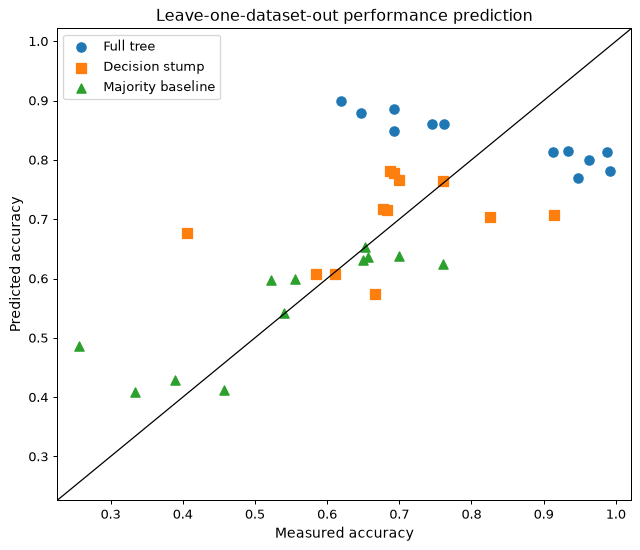

In [7]:
actual_best = observed.argmax(axis=1)
predicted_best = predicted_performance.argmax(axis=1)
baseline_best = mean_baseline.argmax(axis=1)
labels = np.array([strategy_names[column] for column in performance_columns])

ranking_summary = pd.DataFrame({
    'dataset': meta_data.dataset,
    'predicted_best': labels[predicted_best],
    'measured_best': labels[actual_best],
    'correct_recommendation': predicted_best == actual_best,
})
display(ranking_summary)
print(f'Meta-model top recommendation accuracy: {(predicted_best == actual_best).mean():.3f}')
print(f'Mean-performance baseline top recommendation accuracy: {(baseline_best == actual_best).mean():.3f}')

fig, ax = plt.subplots(figsize=(7, 6), layout='constrained')
markers = ['o', 's', '^']
for index, column in enumerate(performance_columns):
    ax.scatter(observed[:, index], predicted_performance[:, index], marker=markers[index], s=55,
               label=strategy_names[column])
limits = [min(observed.min(), predicted_performance.min()) - .03,
          max(observed.max(), predicted_performance.max()) + .03]
ax.plot(limits, limits, color='black', linewidth=1)
ax.set(xlim=limits, ylim=limits, xlabel='Measured accuracy', ylabel='Predicted accuracy',
       title='Leave-one-dataset-out performance prediction')
ax.legend()
plt.show()

**Observation:** Inspect the predicted-versus-measured plot and the recommendation table.

In the retained reference run, the top strategy is identified for 9 of the 12 datasets. The simple mean-performance baseline also identifies the top strategy for 9 of 12, so the clearest gain here is improved performance estimation rather than a higher top-one recommendation rate.

**Explanation:** Why is predicting approximate performance a richer meta-learning task than predicting only a winner label?

The predicted values preserve how large the expected differences are. They can support rankings, reveal uncertain near ties and show when a wrong top recommendation has only a small performance cost.

## 6. Inspect one recommendation interactively

Select a dataset, a meta-feature, and a candidate strategy. Compare predicted and measured performance and inspect the resulting ranking.

**Prediction:** Choose one dataset before interacting. Which strategy do you expect to rank first?

The prediction should be made from the dataset descriptors and the patterns observed so far, before revealing the measured ranking in the interactive view.

In [8]:
performance_lab = interactive_meta_performance(meta_data, performance_predictions)
display(performance_lab.widget)

**Observation:** Find one dataset for which the predicted ranking is close to the measured ranking and one where it is not.

Most datasets retain the full tree at the top of both rankings, while the stump-winning datasets provide useful failure cases to inspect.

**Explanation:** Which dataset-level descriptors might help explain the difference?

The interactive view lets us examine whether size, dimensionality, class structure or numeric-feature proportion place the selected task near other tasks with similar measured performance. None of these summaries should be interpreted as a causal explanation by itself.

## 7. Use a shallow tree as an explanation lens

The random forest above is the evaluated performance predictor. Fit a separate shallow regression tree only to visualise how a few meta-feature thresholds can partition dataset space when explaining full-tree performance.

**Prediction:** What does a leaf value represent in this meta-tree?

A leaf value is the average full-tree accuracy of the training tasks that reach that region of meta-feature space.

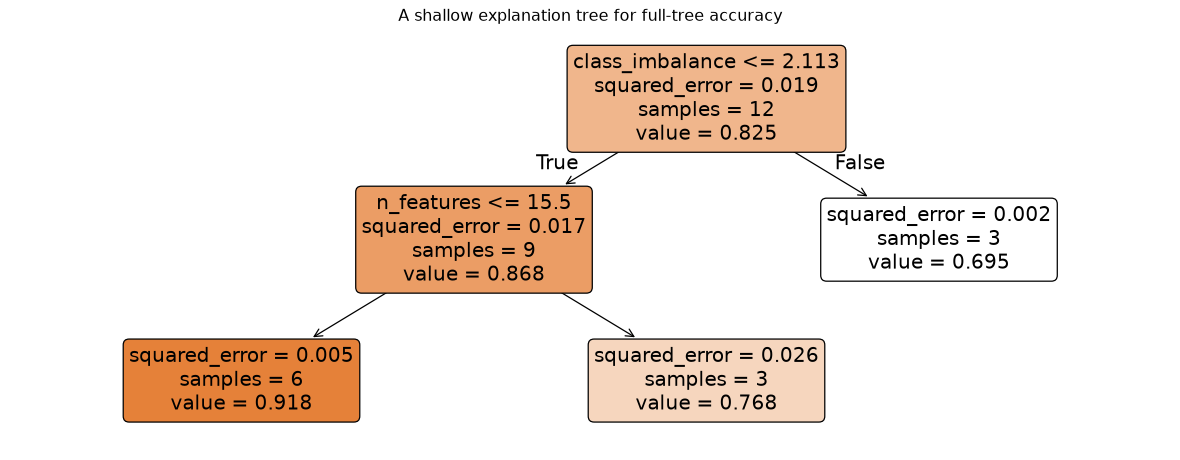

In [9]:
explanation_tree = DecisionTreeRegressor(max_depth=2, min_samples_leaf=2, random_state=0)
explanation_tree.fit(meta_data[meta_features], meta_data.tree_accuracy)
fig, ax = plt.subplots(figsize=(13, 5), layout='constrained')
plot_tree(explanation_tree, feature_names=meta_features, filled=True, rounded=True, precision=3, ax=ax)
ax.set_title('A shallow explanation tree for full-tree accuracy')
plt.show()

**Observation:** Trace one path from the root to a leaf and state the meta-feature conditions it uses.

In the retained reference run, the shallow tree first splits on class imbalance and then uses feature count for the lower-imbalance tasks. Each path therefore defines a region of dataset space and assigns one approximate performance level to it.

**Explanation:** How does this tree connect ordinary feature-space partitioning with meta-learning across datasets? What limitation should remain in mind with only twelve tasks?

The mechanism is the same as an ordinary regression tree, but each point is now an entire dataset and each coordinate is a meta-feature. The example is useful for interpreting the idea of learning across datasets, but twelve tasks are too few to support strong claims about general algorithm-selection performance.